In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
import numpy as np
import os

In [3]:
DECISION_FILTER = "approved" # "approved" or "all_decisions"
DATASET_FILTER = "" # "" or "_pars"

In [4]:
DATASET_DIR = f"./../data/datasets/1995{DATASET_FILTER}/{DECISION_FILTER}"

EMA = f"{DATASET_DIR}/EMA.csv"
PMDA = f"{DATASET_DIR}/PMDA.csv"
SWISSMEDIC = f"{DATASET_DIR}/Swissmedic.csv"
TGA = f"{DATASET_DIR}/TGA.csv"
# FDA = f"{DATASET_DIR}/FDA.csv"
# HEALTHCANADA = f"{DATASET_DIR}/HealthCanada.csv"
OVERALL = f"{DATASET_DIR}/Overall.csv"

SAVE_DIR = f"./../analysis/1995{DATASET_FILTER}/{DECISION_FILTER}/overlap"
os.makedirs(SAVE_DIR, exist_ok=True)

In [5]:
ema = pd.read_csv(EMA)
pmda = pd.read_csv(PMDA)
swissmedic = pd.read_csv(SWISSMEDIC)
tga = pd.read_csv(TGA)
# fda = pd.read_csv(FDA)
# healthcanada = pd.read_csv(HEALTHCANADA)
overall = pd.read_csv(OVERALL)

In [6]:
overall.head()

,Administration_route,Application_date,Application_year,Current_status,Dataset,Decision,Decision_date,Decision_year,Disease_class(es),Document_name,...,Marketing_authorisation_number,Non_proprietary_name,Nonclinical_abridged,Orphan_drug_status,Pharmaceutical_form,Procedure_number,Referral_body,Agency,Disease_name(s),DRUG_CODE
0,subcutaneous,03.06.2013,2013.0,authorised,ema,approved,26.06.2014,2014,"endocrine, nutritional, and metabolic diseases",abasria-epar-public-assessment-report_en.pdf,...,ema/chmp/340840/2014,insulin glargine,no,no,solution,emea/h/c/002835/0000,na,EMA,NaN,NaN
1,intravenous,30.04.2020,2020.0,authorised,ema,approved,24.06.2021,2021,neoplasms; diseases of the blood and blood-for...,abecma-epar-public-assessment-report_en.pdf,...,ema/409800/2021,idecabtagene vicleucel,no,yes,dispersion,emea/h/c/004662/0000,na,EMA,NaN,NaN
2,intramuscular,30.11.2012,2012.0,authorised,ema,approved,19.09.2013,2013,mental and behavioural disorders,abilify-maintena-epar-public-assessment-report...,...,ema/737723/2013,aripiprazole,no,no,powder; solvent,emea/h/c/002755/0000,na,EMA,NaN,NaN
3,oral,12.09.2019,2019.0,authorised,ema,approved,25.02.2021,2021,neoplasms,abiraterone-accord-epar-public-assessment-repo...,...,ema/174959/2021,abiraterone acetate,yes,no,tablet,emea/h/c/005408/0000,NaN,EMA,NaN,NaN
4,oral,29.06.2020,2020.0,authorised,ema,approved,22.04.2021,2021,neoplasms,abiraterone-krka-epar-public-assessment-report...,...,ema/653711/2021,abiraterone acetate,yes,no,tablet,emea/h/c/005649/0000,NaN,EMA,NaN,NaN


In [7]:
def plot_agency_distribution(dataset, data_col, figsize=(4.2, 4.2), bar_color='darkseagreen', 
                            edge_color='navy', xlabel_fontsize=12, ylabel_fontsize=12):
    plt.figure(figsize=figsize)
    
    agency_counts = dataset.groupby(data_col)['Agency'].nunique()
    agency_counts.value_counts().sort_index().plot(kind='bar', color=bar_color, edgecolor=edge_color)
    
    plt.xlabel(f'$N$ drug agencies', fontsize=xlabel_fontsize)
    plt.ylabel(f'$N$ {data_col.lower().replace("_", " ")}', fontsize=ylabel_fontsize)
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate(agency_counts.value_counts().sort_index()):
        plt.text(i, v + max(agency_counts.value_counts()) * 0.001, str(v), 
                 ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{data_col}_agency_distribution.png", dpi=300)
    plt.show()

def create_normalized_heatmap(dataset=overall, data_col='Drug_name', figsize=(5, 4), cmap='Greens'):
    agencies = dataset['Agency'].unique()
    heatmap = pd.DataFrame(0, index=agencies, columns=agencies)

# Get the total number of drugs per agency
    agency_drug_counts = dataset.groupby('Agency')[data_col].nunique()
    for drug in dataset[data_col].unique():
        involved_agencies = dataset[dataset[data_col] == drug]['Agency'].unique()
        for agency1, agency2 in combinations(involved_agencies, 2):
            heatmap.loc[agency1, agency2] += 1
            heatmap.loc[agency2, agency1] += 1

# Normalize by column (x-axis) agency's total drug count
    heatmap_normalized = heatmap.copy()
    for j, agency_col in enumerate(agencies):  # j is column (x-axis)
        for i, agency_row in enumerate(agencies):  # i is row (y-axis)
            if i != j:
            # Divide by the column agency's total drugs
                heatmap_normalized.loc[agency_row, agency_col] = (
                heatmap.loc[agency_row, agency_col] / agency_drug_counts[agency_col]
            )

    plt.figure(figsize=figsize)
    plt.imshow(heatmap_normalized, cmap=cmap, interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar(label='Proportion of Column Agency Drugs')
    plt.xticks(ticks=np.arange(len(agencies)), labels=agencies, rotation=45)
    plt.yticks(ticks=np.arange(len(agencies)), labels=agencies)

# Add text with absolute and percentage values
    for i in range(len(agencies)):
        for j in range(len(agencies)):
            if i != j:  # Skip diagonal
                abs_value = int(heatmap.iloc[i, j])
                prop_value = heatmap_normalized.iloc[i, j]
            # text_color = 'white' if prop_value > 0.5 else 'black'
                text_color = "black"
                # round percent to integer if >=10%, else 1 decimal place
                if prop_value >= 0.1:
                    prop_text = f'{prop_value:.0%}'
                else:
                    prop_text = f'{prop_value:.1%}'
                plt.text(j, i, f'{abs_value}\n({prop_text})', 
                    ha='center', va='center', 
                    color=text_color, fontsize=9)

    # plt.title('Shared Drugs (% of horizontal axis agency)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{data_col}_normalized_heatmap.png", dpi=300)
    plt.show()

def analyze_drug_duplicates(dataset, data_col, top_n_drugs=2):

    # Create a subset df with drug names which appear multiple times within the SAME agency
    duplicates_within_agency = dataset[dataset.duplicated(subset=[data_col, 'Agency'], keep=False)]
    
    # Find drug names which are cross-agency duplicates (appear in multiple different agencies)
    cross_agency_duplicates = dataset[dataset.duplicated(subset=[data_col], keep=False)]
    
    # Drop in-agency duplicates from this subset to keep only cross-agency duplicates
    cross_agency_duplicates = cross_agency_duplicates[~cross_agency_duplicates.index.isin(duplicates_within_agency.index)]
    
    # Find the top shared drugs across multiple agencies and create df subset with them
    drug_agency_count = dataset.groupby(data_col)['Agency'].nunique()
    top_shared_drugs = drug_agency_count[drug_agency_count > top_n_drugs].index.tolist()
    top_shared_drugs_df = dataset[dataset[data_col].isin(top_shared_drugs)]
    
    print(20 * "-")
    print(f"{len(dataset):<10} Length of the combined (overall) dataset including all datapoints")
    print(f"{len(duplicates_within_agency):<10} Length of the subset including in-agency duplicates ({data_col} present multiple times within the same agency)")
    print(f"{len(cross_agency_duplicates):<10} Length of the subset including cross-agency duplicates ({data_col} present in multiple different agencies)")
    print(20 * "-")
    print(f"{dataset[data_col].nunique():<10} N of unique {data_col} in the combined dataset")
    print(f"{duplicates_within_agency[data_col].nunique():<10} N of unique {data_col} in the in-agency duplicates subset")
    print(f"{cross_agency_duplicates[data_col].nunique():<10} N of unique {data_col} in the cross-agency duplicates subset")
    
    return {
        'duplicates_within_agency': duplicates_within_agency,
        'cross_agency_duplicates': cross_agency_duplicates,
        'top_shared_drugs_df': top_shared_drugs_df,
        'top_shared_drugs': top_shared_drugs
    }

In [8]:
def analyze_agency_drug_sharing(dataset, data_col='Drug_name', output_file=None):

    agencies = sorted(dataset['Agency'].unique())
    
    # Filter out rows with missing drug names
    dataset_clean = dataset[dataset[data_col].notna()].copy()
    
    # Create a mapping of drug to set of agencies
    drug_to_agencies = dataset_clean.groupby(data_col)['Agency'].apply(set).to_dict()
    
    # Initialize results dictionary
    results = {agency: {} for agency in agencies}
    
    # Prepare output capture
    output_lines = []
    
    # For each agency, analyze its drugs
    for agency in agencies:
        # Get unique drugs for this agency, excluding NaN values
        agency_drugs = dataset_clean[dataset_clean['Agency'] == agency][data_col].unique()
        total_drugs = len(agency_drugs)
        
        if total_drugs == 0:
            continue
        
        # Count how many agencies each drug appears in (beyond the current agency)
        sharing_counts = {}
        for drug in agency_drugs:
            agencies_with_drug = drug_to_agencies.get(drug, set())
            # Count other agencies (excluding current agency)
            n_other_agencies = len(agencies_with_drug) - 1
            sharing_counts[n_other_agencies] = sharing_counts.get(n_other_agencies, 0) + 1
        
        # Calculate percentages
        for n_shared in sharing_counts:
            percentage = (sharing_counts[n_shared] / total_drugs) * 100
            results[agency][n_shared] = percentage
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results).T
    results_df = results_df.fillna(0).sort_index(axis=1)
    
    # Rename columns for clarity
    column_names = {}
    for col in results_df.columns:
        if col == 0:
            column_names[col] = 'Unique to agency'
        elif col == 1:
            column_names[col] = 'Shared with 1 other'
        else:
            column_names[col] = f'Shared with {col} others'
    results_df = results_df.rename(columns=column_names)
    
    # Display results
    def print_and_capture(text):
        print(text)
        output_lines.append(text)
    
    print_and_capture(f"\n{'='*80}")
    print_and_capture(f"Drug Sharing Analysis by Agency (unique deduped entries based on {data_col})")
    print_and_capture(f"{'='*80}\n")
    
    print_and_capture(f"Percentages represent proportion of each agency's unique deduped entries by {data_col}:\n")
    print_and_capture(results_df.round(2).to_string())
    
    # Also print absolute counts
    print_and_capture(f"\n\n{'='*80}")
    print_and_capture(f"Absolute counts (by unique deduped entry in {data_col}):")
    print_and_capture(f"{'='*80}\n")
    
    # Calculate absolute counts
    counts_results = {agency: {} for agency in agencies}
    for agency in agencies:
        agency_drugs = dataset_clean[dataset_clean['Agency'] == agency][data_col].unique()
        total_drugs = len(agency_drugs)
        
        if total_drugs == 0:
            continue
        
        sharing_counts = {}
        for drug in agency_drugs:
            agencies_with_drug = drug_to_agencies.get(drug, set())
            n_other_agencies = len(agencies_with_drug) - 1
            sharing_counts[n_other_agencies] = sharing_counts.get(n_other_agencies, 0) + 1
        
        for n_shared in sharing_counts:
            counts_results[agency][n_shared] = sharing_counts[n_shared]
    
    counts_df = pd.DataFrame(counts_results).T
    counts_df = counts_df.fillna(0).sort_index(axis=1).astype(int)
    counts_df = counts_df.rename(columns=column_names)
    
    print_and_capture(counts_df.to_string())
    
    # Summary statistics
    print_and_capture(f"\n\n{'='*80}")
    print_and_capture(f"Summary Statistics by unique deduped {data_col}:")
    print_and_capture(f"{'='*80}\n")
    
    for agency in agencies:
        total = len(dataset_clean[dataset_clean['Agency'] == agency][data_col])
        total_deduped = dataset_clean[dataset_clean['Agency'] == agency][data_col].nunique()
        unique = counts_df.loc[agency, 'Unique to agency'] if 'Unique to agency' in counts_df.columns else 0
        print_and_capture(f"{agency:15} - Total: {total:4}, Total deduped: {total_deduped:4}, Unique to this agency: {unique:4} ({unique/total_deduped*100:.1f}%)")
    
    # Save to file if output_file is specified
    if output_file:
        with open(output_file, 'w', encoding='utf-8') as f:
            f.write('\n'.join(output_lines))
        print(f"\n Analysis saved to: {output_file}")
    
    return results_df, counts_df

In [9]:
def get_top_duplicated_drugs(dataset, data_col='Drug_name', top_n=15):

    # Filter out rows with missing values in data_col
    dataset_clean = dataset[dataset[data_col].notna()].copy()
    
    # Count occurrences of each drug
    drug_counts = dataset_clean[data_col].value_counts()
    
    # Get top N drugs with most duplicates
    top_drugs = drug_counts.head(top_n).index.tolist()
    
    # Filter dataset for these top drugs
    top_drugs_df = dataset_clean[dataset_clean[data_col].isin(top_drugs)].copy()
    
    # Sort by data_col and then by Agency for easy comparison
    top_drugs_df = top_drugs_df.sort_values([data_col, 'Agency'])
    
    print(f"\nTop {top_n} drugs with most entries (by {data_col}):")
    print(f"{'='*80}\n")
    for i, (drug, count) in enumerate(drug_counts.head(top_n).items(), 1):
        agencies = dataset_clean[dataset_clean[data_col] == drug]['Agency'].unique()
        print(f"{i:2}. {drug:40} - {count:3} entries across {len(agencies)} agencies: {', '.join(sorted(agencies))}")
    
    # save for inspection
    top_drugs_df.to_csv(f"{SAVE_DIR}/top_{top_n}_duplicated_drugs_by_{data_col}.csv", index=False)
    
    return top_drugs_df

In [10]:
overall.head(2)

,Administration_route,Application_date,Application_year,Current_status,Dataset,Decision,Decision_date,Decision_year,Disease_class(es),Document_name,...,Marketing_authorisation_number,Non_proprietary_name,Nonclinical_abridged,Orphan_drug_status,Pharmaceutical_form,Procedure_number,Referral_body,Agency,Disease_name(s),DRUG_CODE
0,subcutaneous,03.06.2013,2013.0,authorised,ema,approved,26.06.2014,2014,"endocrine, nutritional, and metabolic diseases",abasria-epar-public-assessment-report_en.pdf,...,ema/chmp/340840/2014,insulin glargine,no,no,solution,emea/h/c/002835/0000,na,EMA,NaN,NaN
1,intravenous,30.04.2020,2020.0,authorised,ema,approved,24.06.2021,2021,neoplasms; diseases of the blood and blood-for...,abecma-epar-public-assessment-report_en.pdf,...,ema/409800/2021,idecabtagene vicleucel,no,yes,dispersion,emea/h/c/004662/0000,na,EMA,NaN,NaN


# Analyse duplicates by drug_name

In [11]:
results = analyze_drug_duplicates(dataset=overall, data_col='Drug_name', top_n_drugs=10)

--------------------
31964      Length of the combined (overall) dataset including all datapoints
22631      Length of the subset including in-agency duplicates (Drug_name present multiple times within the same agency)
2823       Length of the subset including cross-agency duplicates (Drug_name present in multiple different agencies)
--------------------
10756      N of unique Drug_name in the combined dataset
3566       N of unique Drug_name in the in-agency duplicates subset
1217       N of unique Drug_name in the cross-agency duplicates subset


In [12]:
print(results)

{'duplicates_within_agency':             Administration_route Application_date  Application_year  \
1042   intravenous; subcutaneous              NaN               NaN   
1128   intravenous; subcutaneous              NaN               NaN   
1491                 intravenous       31.03.2009            2009.0   
1494                 intravenous       26.04.2011            2011.0   
1506                        oral       08.08.2006            2006.0   
...                          ...              ...               ...   
31958                intravenous              NaN               NaN   
31960                       oral              NaN               NaN   
31961                       oral              NaN               NaN   
31962                       oral              NaN               NaN   
31963                       oral              NaN               NaN   

      Current_status       Dataset  Decision Decision_date  Decision_year  \
1042      authorised           ema  appro

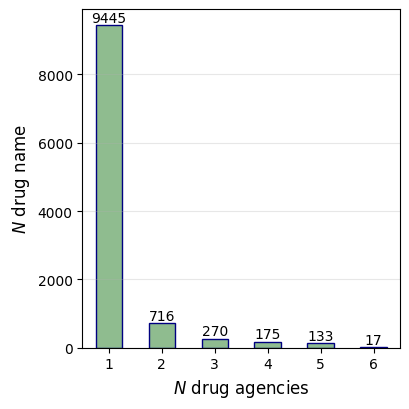

In [13]:
plot_agency_distribution(overall, 'Drug_name')

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_32104\3832251816.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.11006711409395974' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  heatmap_normalized.loc[agency_row, agency_col] = (
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_32104\3832251816.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5239616613418531' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  heatmap_normalized.loc[agency_row, agency_col] = (
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_32104\3832251816.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.8402061855670103' has dtype incompatible with int64, please explicitly cast t

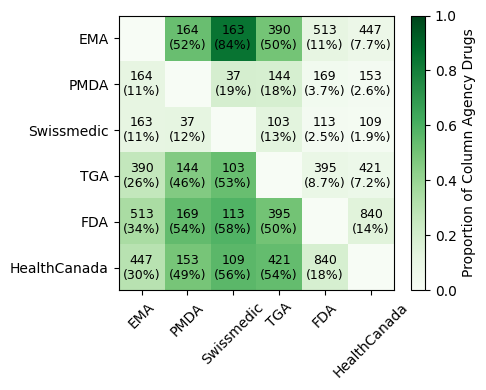

In [14]:
create_normalized_heatmap(dataset=overall, data_col='Drug_name', figsize=(5, 4), cmap='Greens')

In [15]:
analyze_agency_drug_sharing(dataset=overall, data_col='Drug_name', output_file=f"{SAVE_DIR}/drug_name_analysis.txt")


Drug Sharing Analysis by Agency (unique deduped entries based on Drug_name)

Percentages represent proportion of each agency's unique deduped entries by Drug_name:

              Unique to agency  Shared with 1 other  Shared with 2 others  Shared with 3 others  Shared with 4 others  Shared with 5 others
EMA                      51.21                16.71                 11.61                 10.40                  8.93                  1.14
FDA                      76.83                11.83                  4.73                  3.39                  2.84                  0.37
HealthCanada             83.20                 7.92                  3.60                  2.76                  2.23                  0.29
PMDA                     32.59                 8.95                  9.27                 16.61                 27.16                  5.43
Swissmedic               10.31                16.49                 14.43                 18.56                 31.44                 

(              Unique to agency  Shared with 1 other  Shared with 2 others  \
 EMA                  51.208054            16.711409             11.610738   
 FDA                  76.833297            11.825589              4.734640   
 HealthCanada         83.196159             7.921811              3.600823   
 PMDA                 32.587859             8.945687              9.265176   
 Swissmedic           10.309278            16.494845             14.432990   
 TGA                  27.933673            15.816327             19.770408   
 
               Shared with 3 others  Shared with 4 others  Shared with 5 others  
 EMA                      10.402685              8.926174              1.140940  
 FDA                       3.391323              2.840784              0.374367  
 HealthCanada              2.760631              2.229081              0.291495  
 PMDA                     16.613419             27.156550              5.431310  
 Swissmedic               18.556701       

In [16]:
# Get top 15 drugs with most duplicates
top_duplicated_df = get_top_duplicated_drugs(dataset=overall, data_col='Drug_name', top_n=15)
top_duplicated_df.head(3)


Top 15 drugs with most entries (by Drug_name):

 1. metformin hydrochloride                  - 104 entries across 1 agencies: FDA
 2. levetiracetam                            - 100 entries across 2 agencies: FDA, HealthCanada
 3. hydrocodone bitartrate and acetaminophen -  98 entries across 1 agencies: FDA
 4. famotidine                               -  79 entries across 2 agencies: FDA, HealthCanada
 5. gabapentin                               -  78 entries across 2 agencies: FDA, HealthCanada
 6. pregabalin                               -  75 entries across 2 agencies: FDA, HealthCanada
 7. ranitidine hydrochloride                 -  75 entries across 1 agencies: FDA
 8. clobetasol propionate                    -  74 entries across 1 agencies: FDA
 9. potassium chloride                       -  74 entries across 1 agencies: FDA
10. ibuprofen                                -  72 entries across 2 agencies: FDA, HealthCanada
11. acyclovir                                -  71 entries ac

,Administration_route,Application_date,Application_year,Current_status,Dataset,Decision,Decision_date,Decision_year,Disease_class(es),Document_name,...,Marketing_authorisation_number,Non_proprietary_name,Nonclinical_abridged,Orphan_drug_status,Pharmaceutical_form,Procedure_number,Referral_body,Agency,Disease_name(s),DRUG_CODE
4682,oral,NaN,NaN,authorised,fda,approved,06.03.2014,2014,NaN,NaN,...,anda201445,acyclovir,yes,no,capsule,NaN,no,FDA,NaN,NaN
4696,topical,NaN,NaN,authorised,fda,approved,29.01.2020,2020,NaN,NaN,...,anda201501,acyclovir,yes,no,ointment,NaN,no,FDA,NaN,NaN
4948,oral,NaN,NaN,authorised,fda,approved,15.11.2013,2013,infectious and parasitic diseases,NaN,...,anda202168,acyclovir,yes,no,tablet,NaN,no,FDA,<herpes zoster>; <genital herpes>; <chickenpox>,NaN


# Analyze duplicates by Non_proprietary_name

In [17]:
results = analyze_drug_duplicates(dataset=overall, data_col='Non_proprietary_name', top_n_drugs=10)

--------------------
31964      Length of the combined (overall) dataset including all datapoints
28161      Length of the subset including in-agency duplicates (Non_proprietary_name present multiple times within the same agency)
1657       Length of the subset including cross-agency duplicates (Non_proprietary_name present in multiple different agencies)
--------------------
4549       N of unique Non_proprietary_name in the combined dataset
2102       N of unique Non_proprietary_name in the in-agency duplicates subset
813        N of unique Non_proprietary_name in the cross-agency duplicates subset


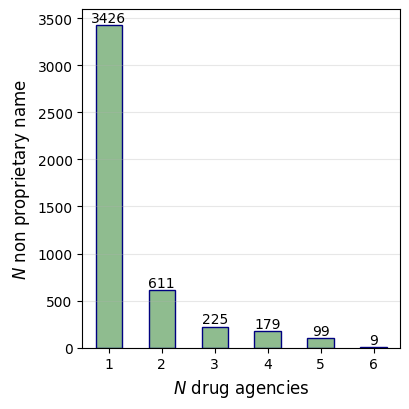

In [18]:
plot_agency_distribution(overall, 'Non_proprietary_name')

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_32104\3832251816.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.16459627329192547' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  heatmap_normalized.loc[agency_row, agency_col] = (
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_32104\3832251816.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5162337662337663' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  heatmap_normalized.loc[agency_row, agency_col] = (
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_32104\3832251816.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6323529411764706' has dtype incompatible with int64, please explicitly cast t

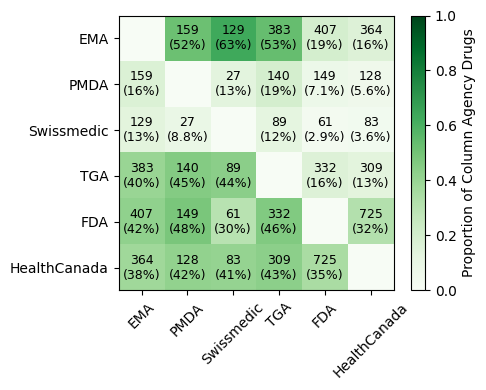

In [19]:
create_normalized_heatmap(dataset=overall, data_col='Non_proprietary_name', figsize=(5, 4), cmap='Greens')

In [20]:
analyze_agency_drug_sharing(dataset=overall, data_col='Non_proprietary_name', output_file=f"{SAVE_DIR}/non_proprietary_name_analysis.txt")


Drug Sharing Analysis by Agency (unique deduped entries based on Non_proprietary_name)

Percentages represent proportion of each agency's unique deduped entries by Non_proprietary_name:

              Unique to agency  Shared with 1 other  Shared with 2 others  Shared with 3 others  Shared with 4 others  Shared with 5 others
EMA                      36.75                17.60                 17.39                 17.08                 10.25                  0.93
FDA                      56.91                23.36                  8.06                  6.82                  4.43                  0.43
HealthCanada             64.91                16.83                  6.50                  7.15                  4.23                  0.39
PMDA                     32.14                13.64                 11.04                 15.58                 24.68                  2.92
Swissmedic               31.37                12.25                 15.69                 20.10                 

(              Unique to agency  Shared with 1 other  Shared with 2 others  \
 EMA                  36.749482            17.598344             17.391304   
 FDA                  56.911344            23.355577              8.055291   
 HealthCanada         64.908457            16.826504              6.495205   
 PMDA                 32.142857            13.636364             11.038961   
 Swissmedic           31.372549            12.254902             15.686275   
 TGA                  31.337047            15.181058             17.130919   
 
               Shared with 3 others  Shared with 4 others  Shared with 5 others  
 EMA                      17.080745             10.248447              0.931677  
 FDA                       6.816015              4.432793              0.428980  
 HealthCanada              7.149085              4.228422              0.392328  
 PMDA                     15.584416             24.675325              2.922078  
 Swissmedic               20.098039       

In [21]:
# Get top 15 drugs with most duplicates by Non_proprietary_name
top_duplicated_nonprop_df = get_top_duplicated_drugs(dataset=overall, data_col='Non_proprietary_name', top_n=15)
top_duplicated_nonprop_df.head(3)


Top 15 drugs with most entries (by Non_proprietary_name):

 1. acetaminophen                            - 347 entries across 2 agencies: FDA, HealthCanada
 2. ethinyl estradiol                        - 234 entries across 1 agencies: FDA
 3. metformin hydrochloride                  - 178 entries across 2 agencies: FDA, HealthCanada
 4. pregabalin                               - 177 entries across 3 agencies: EMA, FDA, HealthCanada
 5. levetiracetam                            - 170 entries across 3 agencies: EMA, FDA, HealthCanada
 6. olanzapine                               - 165 entries across 4 agencies: EMA, FDA, HealthCanada, PMDA
 7. hydrochlorothiazide                      - 147 entries across 2 agencies: FDA, HealthCanada
 8. ibuprofen                                - 142 entries across 4 agencies: EMA, FDA, HealthCanada, TGA
 9. diltiazem hydrochloride                  - 136 entries across 2 agencies: FDA, HealthCanada
10. gabapentin                               - 129 entries 

,Administration_route,Application_date,Application_year,Current_status,Dataset,Decision,Decision_date,Decision_year,Disease_class(es),Document_name,...,Marketing_authorisation_number,Non_proprietary_name,Nonclinical_abridged,Orphan_drug_status,Pharmaceutical_form,Procedure_number,Referral_body,Agency,Disease_name(s),DRUG_CODE
3129,oral,NaN,NaN,discontinued,fda,approved,16.12.1996,1996,NaN,NaN,...,anda040139,acetaminophen,yes,no,tablet,NaN,no,FDA,NaN,NaN
3132,oral,NaN,NaN,discontinued,fda,approved,22.02.1996,1996,NaN,NaN,...,anda040143,acetaminophen,yes,no,tablet,NaN,no,FDA,NaN,NaN
3134,oral,NaN,NaN,discontinued,fda,approved,22.02.1996,1996,NaN,NaN,...,anda040144,acetaminophen,yes,no,tablet,NaN,no,FDA,NaN,NaN


# Create Deduplicated Dataset for Trajectory Analysis

In [33]:
def create_deduplicated_dataset(dataset, data_col='Drug_name', date_col='Decision_date'):
    """
    Deduplicate the dataset by keeping only one instance of each drug per agency.
    For duplicates within the same agency, keep the earliest approval date.
    
    Parameters:
    - dataset: DataFrame with drug approvals
    - data_col: Column name for drug identifier (e.g., 'Drug_name' or 'Non_proprietary_name')
    - date_col: Column name for decision date
    
    Returns:
    - Deduplicated DataFrame
    """
    # Make a copy to avoid modifying the original
    df = dataset.copy()
    
    # Convert date column to datetime
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    
    print(f"Original dataset size: {len(df)}")
    print(f"Unique drugs in original: {df[data_col].nunique()}")
    print(f"\nChecking for duplicates within agencies...")
    
    # Check for duplicates within each agency
    duplicates_within_agency = df[df.duplicated(subset=[data_col, 'Agency'], keep=False)]
    print(f"Rows with duplicates within same agency: {len(duplicates_within_agency)}")
    print(f"Unique drugs affected: {duplicates_within_agency[data_col].nunique()}")
    
    # Sort by date to ensure earliest comes first
    df = df.sort_values([data_col, 'Agency', date_col])
    
    # Keep only the first (earliest) occurrence of each drug-agency combination
    df_deduped = df.drop_duplicates(subset=[data_col, 'Agency'], keep='first')
    
    print(f"\nDeduplicated dataset size: {len(df_deduped)}")
    print(f"Rows removed: {len(df) - len(df_deduped)}")
    print(f"Unique drugs in deduplicated: {df_deduped[data_col].nunique()}")
    
    return df_deduped

In [34]:
# Create deduplicated version of overall dataset for trajectory analysis
overall_deduped = create_deduplicated_dataset(overall, data_col='Drug_name', date_col='Decision_date')

# Save the deduplicated dataset
overall_deduped.to_csv(f"{SAVE_DIR}/overall_deduplicated.csv", index=False)
print(f"\nDeduplicated dataset saved to: {SAVE_DIR}/overall_deduplicated.csv")

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_32104\3391221100.py:18: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')


Original dataset size: 31964
Unique drugs in original: 10756

Checking for duplicates within agencies...
Rows with duplicates within same agency: 22631
Unique drugs affected: 3566

Deduplicated dataset size: 13155
Rows removed: 18809
Unique drugs in deduplicated: 10756

Deduplicated dataset saved to: ./../analysis/1995/approved/overlap/overall_deduplicated.csv


# Analyze Approval Trajectories and Timelines

In [35]:
# First, let's check what date columns are available
print("Columns in overall dataset:")
print(overall.columns.tolist())
print("\nFirst few rows:")
overall.head(3)

Columns in overall dataset:
['Administration_route', 'Application_date', 'Application_year', 'Current_status', 'Dataset', 'Decision', 'Decision_date', 'Decision_year', 'Disease_class(es)', 'Document_name', 'Drug_class', 'Drug_name', 'Indication_approved', 'Indication_approved_extracted', 'Indication_extended', 'Indication_requested', 'Indication_requested_extracted', 'Marketing_authorisation_holder', 'Marketing_authorisation_holder_extracted', 'Marketing_authorisation_number', 'Non_proprietary_name', 'Nonclinical_abridged', 'Orphan_drug_status', 'Pharmaceutical_form', 'Procedure_number', 'Referral_body', 'Agency', 'Disease_name(s)', 'DRUG_CODE']

First few rows:


,Administration_route,Application_date,Application_year,Current_status,Dataset,Decision,Decision_date,Decision_year,Disease_class(es),Document_name,...,Marketing_authorisation_number,Non_proprietary_name,Nonclinical_abridged,Orphan_drug_status,Pharmaceutical_form,Procedure_number,Referral_body,Agency,Disease_name(s),DRUG_CODE
0,subcutaneous,03.06.2013,2013.0,authorised,ema,approved,26.06.2014,2014,"endocrine, nutritional, and metabolic diseases",abasria-epar-public-assessment-report_en.pdf,...,ema/chmp/340840/2014,insulin glargine,no,no,solution,emea/h/c/002835/0000,na,EMA,NaN,NaN
1,intravenous,30.04.2020,2020.0,authorised,ema,approved,24.06.2021,2021,neoplasms; diseases of the blood and blood-for...,abecma-epar-public-assessment-report_en.pdf,...,ema/409800/2021,idecabtagene vicleucel,no,yes,dispersion,emea/h/c/004662/0000,na,EMA,NaN,NaN
2,intramuscular,30.11.2012,2012.0,authorised,ema,approved,19.09.2013,2013,mental and behavioural disorders,abilify-maintena-epar-public-assessment-report...,...,ema/737723/2013,aripiprazole,no,no,powder; solvent,emea/h/c/002755/0000,na,EMA,NaN,NaN


In [23]:
from datetime import datetime
import seaborn as sns
from collections import Counter

def analyze_approval_trajectories(dataset, data_col='Drug_name', date_col='Decision_date', min_agencies=2):
    """
    Analyze the order of approvals across agencies for drugs approved by multiple agencies.
    
    Parameters:
    - dataset: DataFrame with drug approvals
    - data_col: Column name for drug identifier
    - date_col: Column name for decision date
    - min_agencies: Minimum number of agencies for a drug to be included
    """
    # Clean dataset
    dataset_clean = dataset[[data_col, 'Agency', date_col]].copy()
    dataset_clean = dataset_clean.dropna(subset=[data_col, date_col])
    
    # Convert date column to datetime
    dataset_clean[date_col] = pd.to_datetime(dataset_clean[date_col], errors='coerce')
    dataset_clean = dataset_clean.dropna(subset=[date_col])
    
    # Filter for drugs approved by multiple agencies
    drug_agency_counts = dataset_clean.groupby(data_col)['Agency'].nunique()
    multi_agency_drugs = drug_agency_counts[drug_agency_counts >= min_agencies].index
    
    multi_agency_df = dataset_clean[dataset_clean[data_col].isin(multi_agency_drugs)].copy()
    
    # Sort by drug and date
    multi_agency_df = multi_agency_df.sort_values([data_col, date_col])
    
    # Create trajectory strings for each drug
    trajectories = []
    drug_timeline_data = []
    
    for drug in multi_agency_df[data_col].unique():
        drug_data = multi_agency_df[multi_agency_df[data_col] == drug].sort_values(date_col)
        agencies = drug_data['Agency'].tolist()
        dates = drug_data[date_col].tolist()
        
        # Create trajectory string (e.g., "EMA -> PMDA -> TGA")
        trajectory = " -> ".join(agencies)
        trajectories.append(trajectory)
        
        # Store timeline data
        drug_timeline_data.append({
            'drug': drug,
            'trajectory': trajectory,
            'agencies': agencies,
            'dates': dates,
            'n_agencies': len(agencies)
        })
    
    # Count trajectory frequencies
    trajectory_counts = Counter(trajectories)
    
    return trajectory_counts, drug_timeline_data, multi_agency_df

def display_top_trajectories(trajectory_counts, top_n=20):
    """Display the most common approval trajectories"""
    print(f"\n{'='*80}")
    print(f"Top {top_n} Most Common Approval Trajectories")
    print(f"{'='*80}\n")
    
    for i, (trajectory, count) in enumerate(trajectory_counts.most_common(top_n), 1):
        n_agencies = trajectory.count('->') + 1
        print(f"{i:2}. [{count:3} drugs, {n_agencies} agencies] {trajectory}")
    
    return pd.DataFrame(trajectory_counts.most_common(top_n), columns=['Trajectory', 'Count'])

def analyze_inter_agency_lags(drug_timeline_data, output_file=None):
    """
    Analyze time lags between consecutive agency approvals
    """
    lags_data = []
    
    for drug_info in drug_timeline_data:
        agencies = drug_info['agencies']
        dates = drug_info['dates']
        
        for i in range(len(agencies) - 1):
            lag_days = (dates[i+1] - dates[i]).days
            lags_data.append({
                'drug': drug_info['drug'],
                'from_agency': agencies[i],
                'to_agency': agencies[i+1],
                'lag_days': lag_days,
                'lag_months': lag_days / 30.44,  # Average days per month
                'from_date': dates[i],
                'to_date': dates[i+1]
            })
    
    lags_df = pd.DataFrame(lags_data)
    
    # Create agency pair column
    lags_df['agency_pair'] = lags_df['from_agency'] + ' -> ' + lags_df['to_agency']
    
    # Summary statistics by agency pair
    print(f"\n{'='*80}")
    print(f"Time Lag Statistics Between Agencies (consecutive approvals)")
    print(f"{'='*80}\n")
    
    summary = lags_df.groupby('agency_pair').agg({
        'lag_days': ['count', 'mean', 'median', 'std', 'min', 'max']
    }).round(1)
    
    summary.columns = ['Count', 'Mean (days)', 'Median (days)', 'Std (days)', 'Min (days)', 'Max (days)']
    summary = summary.sort_values('Count', ascending=False)
    
    print(summary.to_string())
    
    # Also show in months
    print(f"\n{'='*80}")
    print(f"Time Lag Statistics in Months")
    print(f"{'='*80}\n")
    
    summary_months = lags_df.groupby('agency_pair').agg({
        'lag_months': ['count', 'mean', 'median', 'std', 'min', 'max']
    }).round(1)
    
    summary_months.columns = ['Count', 'Mean (months)', 'Median (months)', 'Std (months)', 'Min (months)', 'Max (months)']
    summary_months = summary_months.sort_values('Count', ascending=False)
    
    print(summary_months.to_string())
    
    # Save to file if requested
    if output_file:
        with open(output_file, 'w', encoding='utf-8') as f:
            f.write(f"{'='*80}\n")
            f.write(f"Time Lag Statistics Between Agencies (consecutive approvals) - DAYS\n")
            f.write(f"{'='*80}\n\n")
            f.write(summary.to_string())
            f.write(f"\n\n{'='*80}\n")
            f.write(f"Time Lag Statistics in Months\n")
            f.write(f"{'='*80}\n\n")
            f.write(summary_months.to_string())
        print(f"\nAnalysis saved to: {output_file}")
    
    return lags_df, summary, summary_months

In [24]:
def plot_trajectory_distribution(trajectory_counts_df, top_n=15, figsize=(12, 6)):
    """Plot the distribution of approval trajectories"""
    plt.figure(figsize=figsize)
    
    top_trajectories = trajectory_counts_df.head(top_n)
    
    plt.barh(range(len(top_trajectories)), top_trajectories['Count'], color='steelblue', edgecolor='navy')
    plt.yticks(range(len(top_trajectories)), top_trajectories['Trajectory'])
    plt.xlabel('Number of Drugs', fontsize=12)
    plt.ylabel('Approval Trajectory', fontsize=12)
    plt.title(f'Top {top_n} Most Common Approval Trajectories', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(top_trajectories['Count']):
        plt.text(v + 0.1, i, str(v), va='center')
    
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/approval_trajectories_top{top_n}.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_lag_distributions(lags_df, figsize=(14, 10)):
    """Plot distributions of time lags between agencies"""
    
    # Get most common agency pairs
    top_pairs = lags_df['agency_pair'].value_counts().head(12).index
    
    fig, axes = plt.subplots(3, 4, figsize=figsize)
    axes = axes.flatten()
    
    for idx, pair in enumerate(top_pairs):
        if idx >= 12:
            break
        
        pair_data = lags_df[lags_df['agency_pair'] == pair]['lag_months']
        
        axes[idx].hist(pair_data, bins=20, color='lightcoral', edgecolor='darkred', alpha=0.7)
        axes[idx].axvline(pair_data.median(), color='navy', linestyle='--', linewidth=2, label=f'Median: {pair_data.median():.1f}')
        axes[idx].set_title(pair, fontsize=10, fontweight='bold')
        axes[idx].set_xlabel('Lag (months)', fontsize=9)
        axes[idx].set_ylabel('Frequency', fontsize=9)
        axes[idx].legend(fontsize=8)
        axes[idx].grid(axis='y', alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(top_pairs), 12):
        axes[idx].axis('off')
    
    plt.suptitle('Distribution of Time Lags Between Agency Approvals', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/approval_lags_distribution.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_lag_heatmap(lags_df, figsize=(8, 6)):
    """Create a heatmap of median lags between agencies"""
    
    # Calculate median lags for each agency pair
    pivot_data = lags_df.groupby(['from_agency', 'to_agency'])['lag_months'].median().reset_index()
    pivot_table = pivot_data.pivot(index='from_agency', columns='to_agency', values='lag_months')
    
    plt.figure(figsize=figsize)
    sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='YlOrRd', 
                cbar_kws={'label': 'Median Lag (months)'},
                linewidths=0.5, linecolor='gray')
    plt.title('Median Time Lag Between Agencies (months)\nFrom (row) to (column)', 
              fontsize=12, fontweight='bold')
    plt.xlabel('To Agency', fontsize=11)
    plt.ylabel('From Agency', fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/approval_lags_heatmap.png", dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
# Run the trajectory analysis using the DEDUPLICATED dataset
trajectory_counts, drug_timeline_data, multi_agency_df = analyze_approval_trajectories(
    dataset=overall_deduped, 
    data_col='Drug_name', 
    date_col='Decision_date', 
    min_agencies=2
)

print(f"\nTotal drugs approved by multiple agencies: {len(drug_timeline_data)}")
print(f"Total unique trajectories: {len(trajectory_counts)}")

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_32104\1916304007.py:20: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dataset_clean[date_col] = pd.to_datetime(dataset_clean[date_col], errors='coerce')



Total drugs approved by multiple agencies: 1296
Total unique trajectories: 569


In [26]:
# Display top trajectories
trajectory_df = display_top_trajectories(trajectory_counts, top_n=20)


Top 20 Most Common Approval Trajectories

 1. [133 drugs, 2 agencies] FDA -> HealthCanada
 2. [ 69 drugs, 2 agencies] FDA -> EMA
 3. [ 50 drugs, 2 agencies] EMA -> TGA
 4. [ 40 drugs, 3 agencies] FDA -> HealthCanada -> HealthCanada
 5. [ 28 drugs, 2 agencies] EMA -> FDA
 6. [ 26 drugs, 2 agencies] EMA -> Swissmedic
 7. [ 25 drugs, 2 agencies] HealthCanada -> FDA
 8. [ 20 drugs, 3 agencies] FDA -> HealthCanada -> TGA
 9. [ 18 drugs, 4 agencies] FDA -> HealthCanada -> HealthCanada -> HealthCanada
10. [ 18 drugs, 3 agencies] FDA -> EMA -> HealthCanada
11. [ 17 drugs, 2 agencies] FDA -> TGA
12. [ 17 drugs, 2 agencies] EMA -> HealthCanada
13. [ 16 drugs, 2 agencies] HealthCanada -> TGA
14. [ 15 drugs, 5 agencies] FDA -> HealthCanada -> HealthCanada -> HealthCanada -> HealthCanada
15. [ 14 drugs, 4 agencies] FDA -> EMA -> HealthCanada -> TGA
16. [ 11 drugs, 4 agencies] FDA -> HealthCanada -> HealthCanada -> TGA
17. [ 10 drugs, 3 agencies] FDA -> TGA -> HealthCanada
18. [  9 drugs, 3 agencie

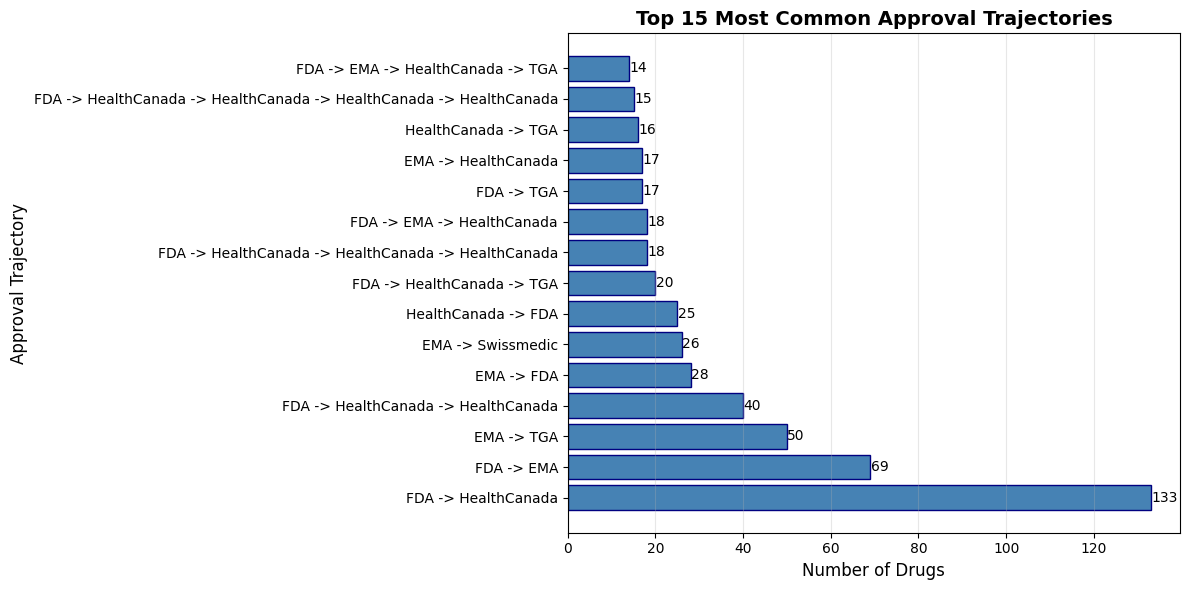

In [27]:
# Plot trajectory distribution
plot_trajectory_distribution(trajectory_df, top_n=15)

In [28]:
# Analyze inter-agency lags
lags_df, lags_summary, lags_summary_months = analyze_inter_agency_lags(
    drug_timeline_data, 
    output_file=f"{SAVE_DIR}/approval_lags_analysis.txt"
)


Time Lag Statistics Between Agencies (consecutive approvals)

                              Count  Mean (days)  Median (days)  Std (days)  Min (days)  Max (days)
agency_pair                                                                                        
FDA -> FDA                     1864        210.2           50.0       459.8           0        5385
HealthCanada -> HealthCanada    956        129.5            0.0       558.8           0        9061
FDA -> HealthCanada             611        700.3          384.0       830.2           0        6103
HealthCanada -> TGA             255        902.9          271.0      1357.2           1        7299
FDA -> EMA                      255        328.5          174.0       626.3           1        7483
HealthCanada -> FDA             249        810.4          371.0      1136.1           0        6345
EMA -> HealthCanada             188        394.7          159.0       620.4           0        3221
EMA -> TGA                      162  

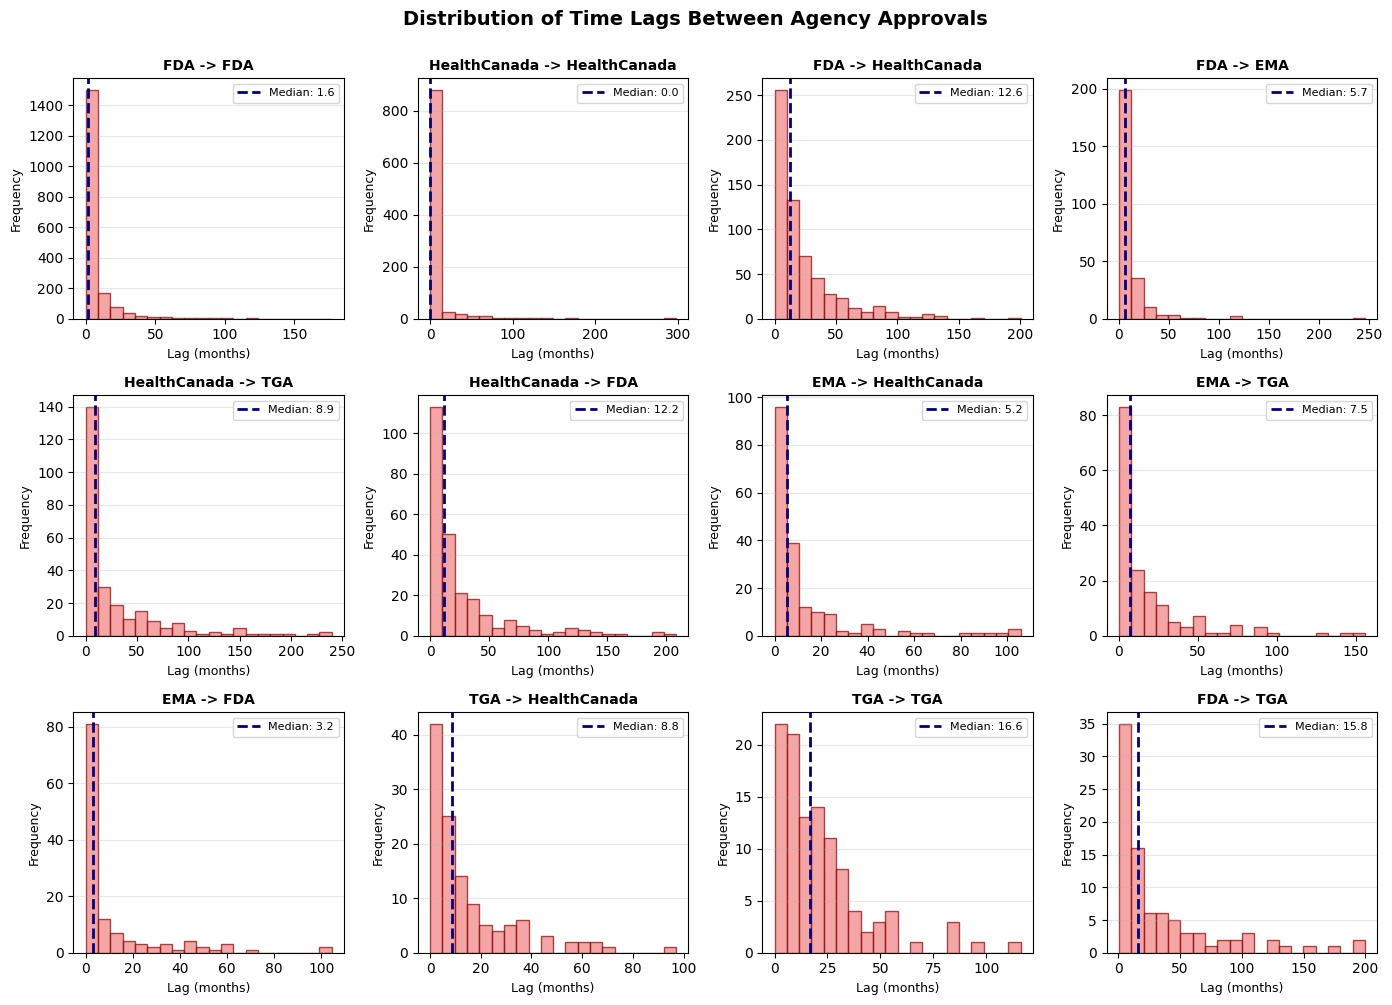

In [29]:
# Plot lag distributions
plot_lag_distributions(lags_df)

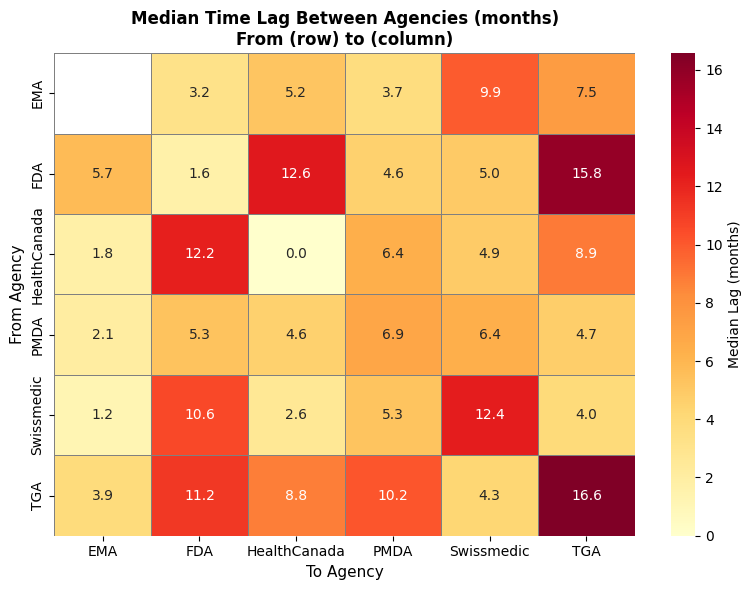

In [30]:
# Plot lag heatmap
plot_lag_heatmap(lags_df)

In [31]:
# View detailed lag data
print("\nSample of drugs with their approval sequences and lags:")
lags_df[['drug', 'from_agency', 'to_agency', 'lag_days', 'lag_months', 'from_date', 'to_date']].head(10)


Sample of drugs with their approval sequences and lags:


,drug,from_agency,to_agency,lag_days,lag_months,from_date,to_date
0,abevmy,TGA,HealthCanada,179,5.880420,2021-05-10,2021-11-05
1,abevmy,HealthCanada,HealthCanada,0,0.000000,2021-11-05,2021-11-05
2,abilify,FDA,FDA,756,24.835742,2002-11-15,2004-12-10
3,abilify,FDA,FDA,544,17.871222,2004-12-10,2006-06-07
4,abilify,FDA,FDA,105,3.449409,2006-06-07,2006-09-20
5,abilify,FDA,HealthCanada,1023,33.607096,2006-09-20,2009-07-09
6,abilify,HealthCanada,HealthCanada,0,0.000000,2009-07-09,2009-07-09
7,abilify,HealthCanada,HealthCanada,0,0.000000,2009-07-09,2009-07-09
8,abilify,HealthCanada,HealthCanada,0,0.000000,2009-07-09,2009-07-09
9,abilify,HealthCanada,HealthCanada,0,0.000000,2009-07-09,2009-07-09


In [32]:
# Save detailed trajectory and lag data
lags_df.to_csv(f"{SAVE_DIR}/approval_lags_detailed.csv", index=False)
trajectory_df.to_csv(f"{SAVE_DIR}/approval_trajectories.csv", index=False)

print(f"\nFiles saved to {SAVE_DIR}:")


Files saved to ./../analysis/1995/approved/overlap:
